# Predictive Maintenance Example Notebook

This example is based on a Kaggle example and adapted by Isabelle Steinhauser on 2nd of June.

The Kaggle  this is based on can be found here: https://www.kaggle.com/code/sharmageetika/predictive-maintenance/notebook

# About Dataset

- UID, Product ID: Unique Identity; Won't be needed in Modeling
- Type:  Product Quality -> L(Low), M(Medium), H(High)
- tool wear failure (TWF), heat dissipation failure (HDF), power failure (PWF), overstrain failure (OSF), random failures (RNF)
- Machine failure: Will be the output variable for the pre maintnance model.
- Kudos to Dataset owner,for sharing it. It is one of the few dataset with detailed explantion to dataset and proper references.

# Import Libraries

In [1]:
!pip install -U "numpy<2" "scipy>=1.11,<1.14" "scikit-learn==1.7.2" "imbalanced-learn" "mlflow" "xgboost>=2.1,<3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 89.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 88.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 94.0 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 99.0 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 84.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 64.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 97.7 MB/s  0:00:03m0:00:0100:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.8
    Uninstalling protobuf-4.25.8:
      Successfully uninstalled protobuf-4.25.8
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/23 [nvidia-nccl-cu12]
    Found existing i

## RESTART KERNEL!!
In order for the newly installed package versions you need to restart kernel (Kernel > Restart Kernel)

In [1]:
import joblib
import mlflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE

# MLflow Setup

In [26]:
mlflow.set_experiment("predictive-maintenance")
mlflow.autolog(log_models=True, silent=True)

print("MLflow experiment: predictive-maintenance")
    

MLflow experiment: predictive-maintenance

[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=50; 

# Data Analysis

In [4]:
dataset = pd.read_csv('ai4i2020.csv')
dataset.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
dataset.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
dataset.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
dataset.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
print(dataset['Machine failure'].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


The above calculation state that the result is highly biased towards 'Machine failure' = 0, hence we need to sample the data. As of now I am thinking of oversampling in order not to loose any information. If that won't work we can gave a look at other sampling methods.

In [9]:
# Check for duplicate rows
duplicates = dataset.duplicated()

# Count the number of duplicate rows
num_duplicates = duplicates.sum()

print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


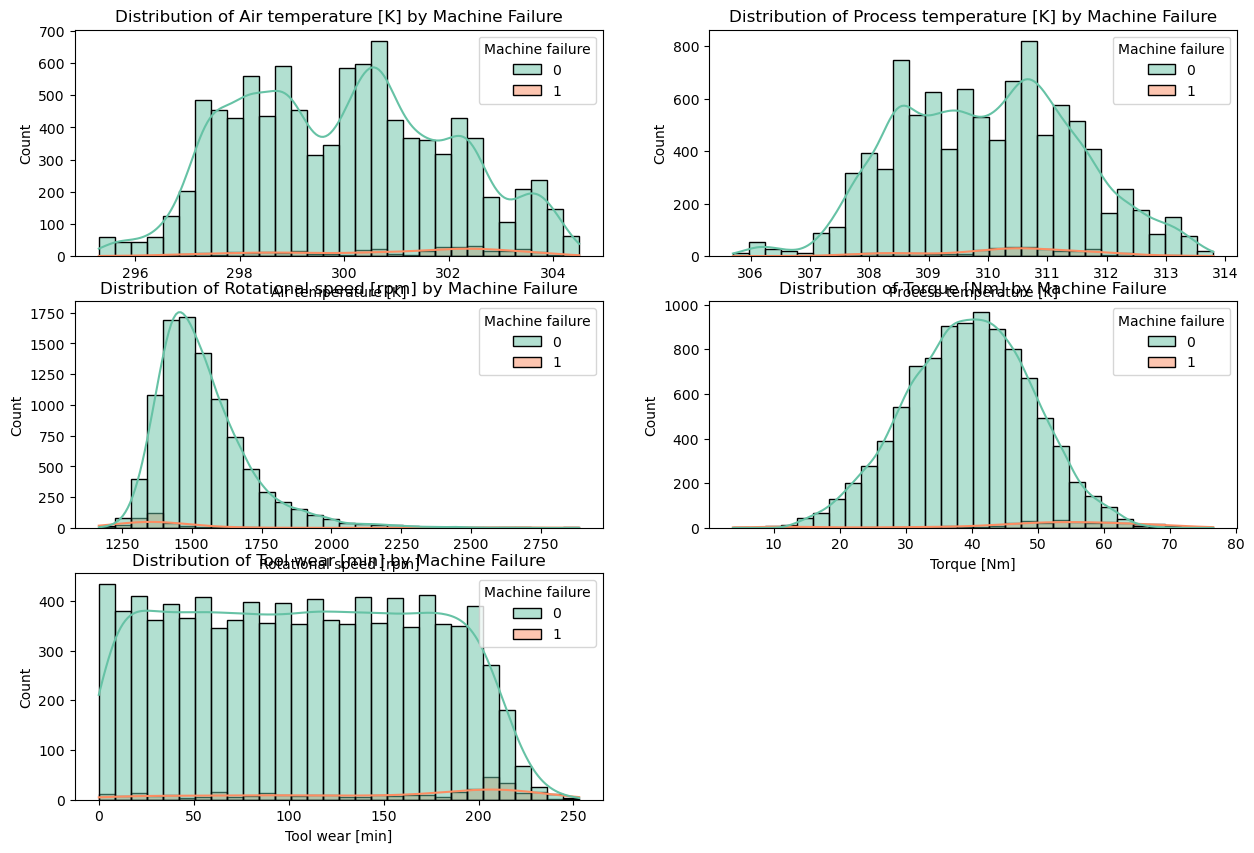

In [10]:
# Visualising Continuous variables
continuous_vars = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Plot distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=dataset, x=col, hue='Machine failure', kde=True, bins=30, palette='Set2')
    plt.title(f'Distribution of {col} by Machine Failure')


/tmp/ipykernel_481/521737880.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_value, group in df_majority.groupby(bin_column):


Machine failure
0    1665
1     339
Name: count, dtype: int64


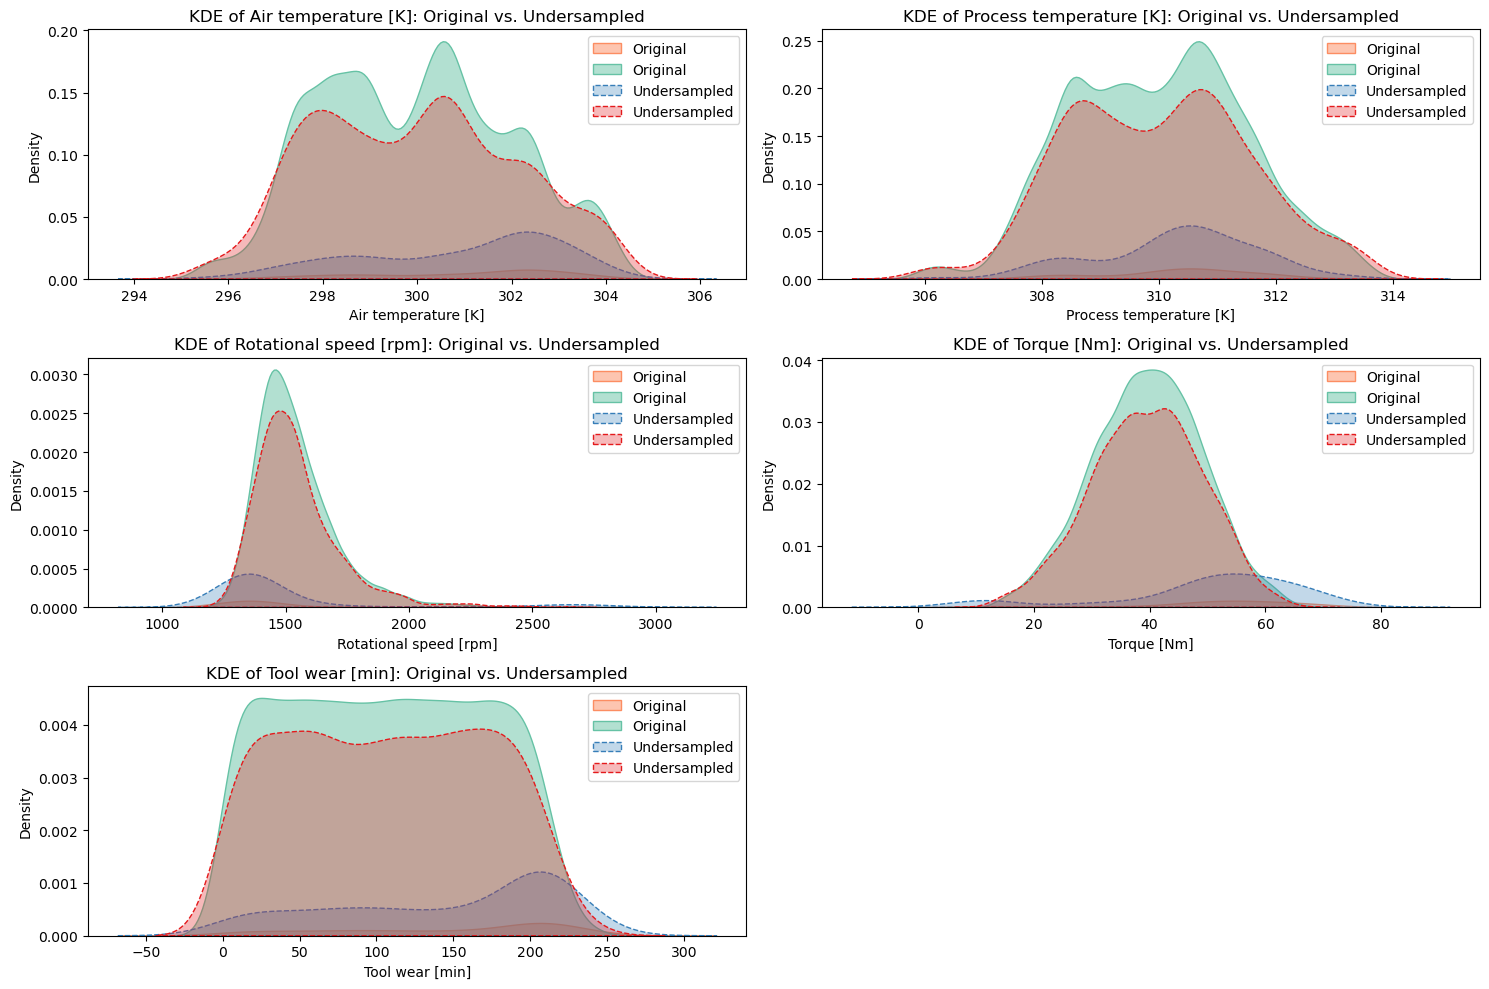

In [11]:
# Maintaing distribution similar as oiginal dataset
# Separate majority and minority classes (explicit copies avoid SettingWithCopyWarning)
df_majority = dataset.loc[dataset['Machine failure'] == 0].copy()
df_minority = dataset.loc[dataset['Machine failure'] == 1].copy()

# Define the target size for undersampling
target_size = len(df_minority)

# Create bins for continuous variables
continuous_vars = ['Air temperature [K]', 'Process temperature [K]', 
                   'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Add bin columns for each continuous variable in the majority class
for col in continuous_vars:
    df_majority.loc[:, f'{col}_bin'] = pd.qcut(df_majority[col], q=10, duplicates='drop')  # Quantile bins

# Perform stratified sampling on the majority class
undersampled_majority = pd.DataFrame()

# For each bin in the continuous variables
for col in continuous_vars:
    bin_column = f'{col}_bin'
    for bin_value, group in df_majority.groupby(bin_column):
        n_samples = int(len(group) / len(df_majority) * target_size)  # Proportional undersampling
        undersampled_majority = pd.concat([undersampled_majority, resample(group, n_samples=n_samples, random_state=42, replace=False)])

# Drop bin columns from the undersampled majority
undersampled_majority = undersampled_majority.drop(columns=[f'{col}_bin' for col in continuous_vars])

# Combine the undersampled majority and minority classes
undersampled_dataset = pd.concat([undersampled_majority, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

# Verify class balance
print(undersampled_dataset['Machine failure'].value_counts())

# Check the distribution (Optional)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_vars, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(data=dataset, x=col, hue='Machine failure', fill=True, alpha=0.5, label='Original', palette='Set2')
    sns.kdeplot(data=undersampled_dataset, x=col, hue='Machine failure', fill=True, alpha=0.3, linestyle='--', label='Undersampled', palette='Set1')
    plt.title(f'KDE of {col}: Original vs. Undersampled')
    plt.legend()

plt.tight_layout()
plt.show()


In [12]:
# Mapping 'Type', product quality; L:1, M:2, H:0
label_encoder = LabelEncoder()
dataset['Labled Type'] = label_encoder.fit_transform(dataset['Type'])
dataset.head()

#Lable Encoding for undersampled dataset as well
undersampled_dataset['Labled Type'] = label_encoder.fit_transform(undersampled_dataset['Type'])
# Though this step can be skipped as form the previous experiments this Feature is not that important for final model

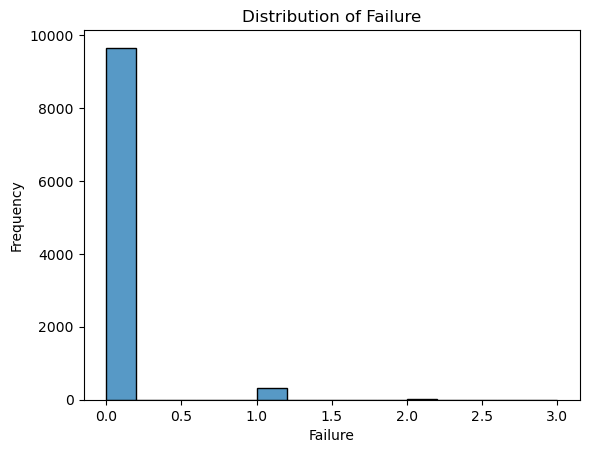

In [13]:
# Investigating Failure
failure_columns = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
dataset['Failure'] = dataset[failure_columns].sum(axis=1)
undersampled_dataset['Failure'] = undersampled_dataset[failure_columns].sum(axis=1)
col = ['Failure']
sns.histplot(data=dataset, x='Failure')
plt.title('Distribution of Failure')
plt.xlabel('Failure')
plt.ylabel('Frequency')
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

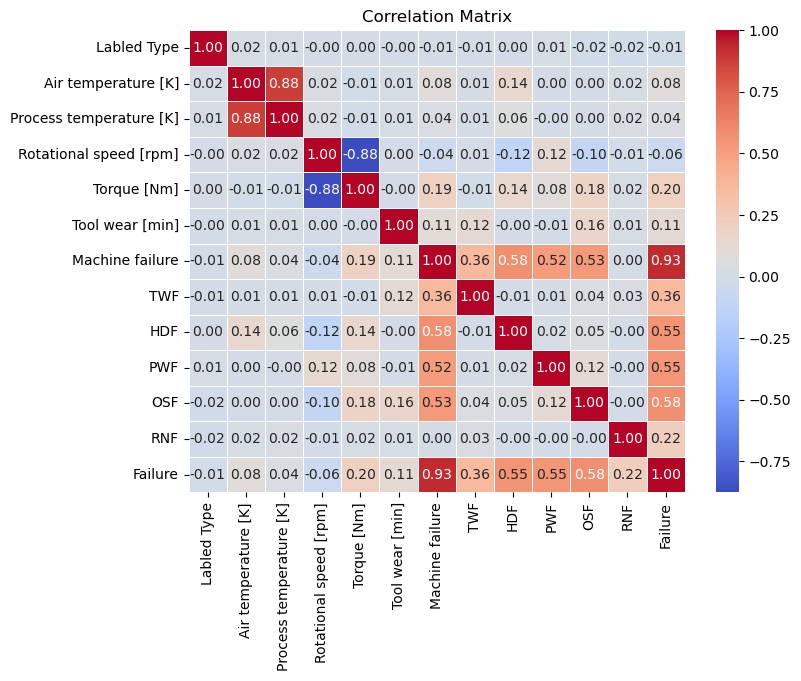

In [14]:
features= ['Labled Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF', 'Failure']

correlation_matrix = dataset[features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')

Text(0.5, 1.0, 'Correlation Matrix')

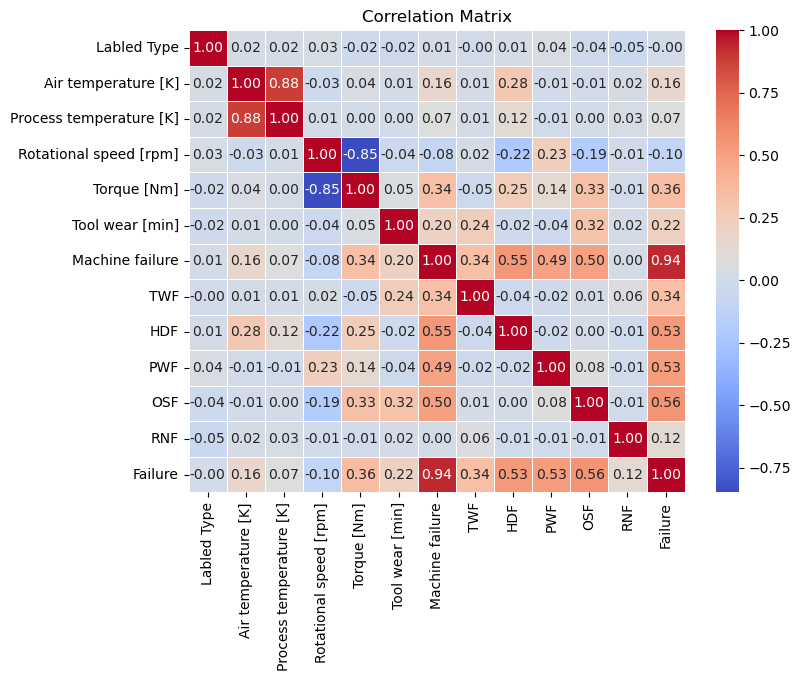

In [15]:
features= ['Labled Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF', 'Failure']

correlation_matrix = undersampled_dataset[features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')

Relation of each type of Failure with other variable:
- tool wear failure (TWF): Tool Wear
- heat dissipation failure (HDF): Torque, Rotational Speed, Air Temperature
- power failure (PWF): Rotational speed, Torque, OSF
- overstrain failure (OSF): Tool Wear. Torque, Rotational Speed
And these Failure further affects the machine Failure.\
From above statement it is clear that above features results in minor failure that further results machine failure.\
Where RNF have minor influence on Machine Failure, TWF hase some inluence on Machine Failure, whereas HDF, PWF, OSF have highly influence on Machine Fialure.

# Assess Feature Importance

Since I have bot catgorical and numerical dataset, hence I am coosing Rnadom Forest Classifirer for Assessing Feature Importance and It has one more benefit that is tis not sensitive to scaling. One might be thinking why not SVM or PCA. But we use SVM the realationship between the target and feature is quite complex. PCA helpful in high dimentionality data. Hence I decided to stick to Rnadom Forest.

In [16]:
X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type'])
y = dataset['Machine failure']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# Get Feature Importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Features': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# Evaluate the model
y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate AUC-ROC
y_pred_prob = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC: {roc_auc:.4f}")

# Cros Validation Score to wheck if the model is overfitting or not
cv_scores = cross_val_score(rf, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


🏃 View run adaptable-donkey-160 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/ee714036dd5148c09c66c1fcc133a0dc
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run polite-conch-563 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/71fe94631dcd4b989871ed163017b0fe
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
                   Features  Importance
11                  Failure    0.511510
2    Rotational speed [rpm]    0.133027
3               Torque [Nm]    0.097305
4           Tool wear [min]    0.070769
7                       PWF    0.047794
8                       OSF    0.035644
6                       HDF    0.029021
5                       TWF    0.022336
0       Air temperature [K]    0.021856
1   Process temperature [K]    0.014518
10              Labled Type    0.014078
9                       RNF    0.002140
Classification Report:
              precision    re

The above Cross-validation state that the model is overfitted, Lets do Feature Selection first and then analyse the model again.

# Feature Selection

I have decied to drop ['TWF', 'HDF', 'PWF', 'OSF','RNF'] as they don't have much influence on the machine failure but collection of which will affect the model all together. I am also droping 'Lable Type' as evern it if provides information of the product quality but that has minor influence on the 'Machine Failure'

In [17]:
X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type',
                         'TWF', 'HDF', 'PWF', 'OSF','RNF', 'Labled Type', 'Failure'])
y = dataset['Machine failure']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_predict = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate AUC-ROC
y_pred_prob = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC: {roc_auc:.4f}")

# Cros Validation Score to wheck if the model is overfitting or not
cv_scores = cross_val_score(rf, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

🏃 View run fearless-kite-842 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/4ae2d3358f78417cb94feb80a59889be
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run trusting-bat-698 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/cafc703d86fc4028984d84bbf32025a6
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       0.92      0.97      0.94        68

    accuracy                           1.00      2000
   macro avg       0.96      0.98      0.97      2000
weighted avg       1.00      1.00      1.00      2000

AUC-ROC: 0.9637
🏃 View run luxuriant-yak-930 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/6406fd55a45644eea9867b0213e3f421
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiment

# Hyper Parameter Tuning

🏃 View run clean-ram-514 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/38f13862fd8a4a7ea6522bd310ece561
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_d

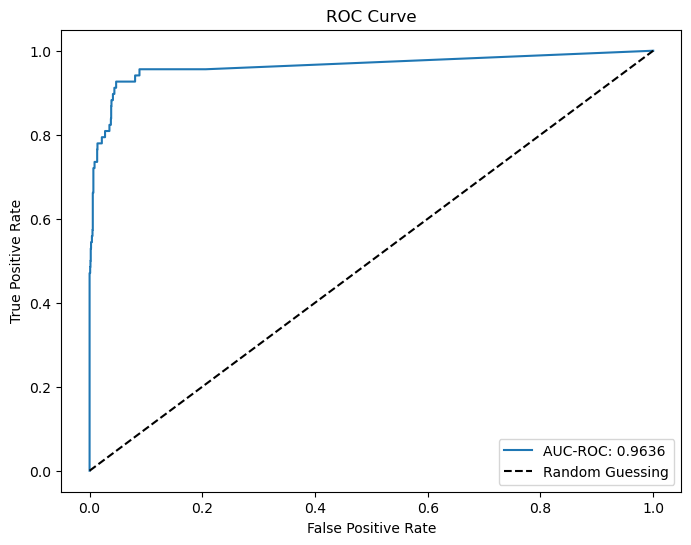

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np


X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type',
                          'TWF', 'HDF', 'PWF', 'OSF','RNF', 'Labled Type', 'Failure'])
y = dataset['Machine failure']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Define the Random Forest model with class weighting
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Set up the parameter grid for hyperparameter tuning
param_grid = {
     'n_estimators': [50, 100, 200],
     'max_depth': [5, 10, 15, None],
     'min_samples_split': [2, 5, 10],
     'min_samples_leaf': [1, 2, 4],
     'max_features': ['sqrt', 'log2', None]
 }

 # Stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

 # Grid Search for hyperparameter tuning
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=cv, scoring='roc_auc', verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

 # Best parameters and model
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

 # Evaluate on test data
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

 # Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

 # AUC-ROC
auc_score = roc_auc_score(y_test, y_prob)
print("AUC-ROC Score:", auc_score)

 # Plot ROC Curve
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC: {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [20]:
# Splitting data into features (X) and target (y)
X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type', 
                          'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Labled Type', 'Failure'])
y = dataset['Machine failure']

# Splitting into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Applying SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Defining the best parameters for the RandomForestClassifier
param_grid = {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 
              'min_samples_split': 2, 'n_estimators': 200}

# Training the RandomForest model
rf_best_model = RandomForestClassifier(random_state=42, class_weight='balanced', **param_grid)
rf_best_model.fit(X_train_resampled, y_train_resampled)

# Predicting the test data
y_pred = rf_best_model.predict(X_test)

# Predicting probabilities for AUC-ROC
y_prob = rf_best_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC-ROC Score:", auc_score)

# Cross-validation for AUC-ROC
cv_scores = cross_val_score(rf_best_model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


🏃 View run likeable-dove-562 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/182fbf8c1d774afa983089f6927ae83e
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run skillful-panda-325 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/d063439704634a6cafcb8f3b06c95667
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.97      1932
           1       0.34      0.81      0.48        68

    accuracy                           0.94      2000
   macro avg       0.67      0.88      0.72      2000
weighted avg       0.97      0.94      0.95      2000

AUC-ROC Score: 0.964643466082085
🏃 View run popular-lark-677 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/922a396055d94d12bc0e559c26b8d7f8
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.loca

I am still mot satisfied with the above model.

# Check Features Multicollinearity
A **variance inflation factor (VIF)** score is a regression diagnostic that measures the correlation between independent variables in a model. It's used to detect multicollinearity, which can affect the reliability of a model's coefficients.\

**What does a VIF score indicate?**\ 
- VIF = 1: No correlation between the variables
- VIF between 1 and 5: Moderate correlation between the variables
- VIF greater than 5: High correlation between the variables
- VIF greater than 10: Serious correlation between the variables

In [21]:
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

🏃 View run welcoming-gnat-309 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/1b89b5a393af4e3b9ba61805eece1b3c
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run melodic-smelt-111 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/dc8ea53f2fcd4ae584f94de312284ccf
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run upset-owl-174 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/9672296aa70440efb0be970f5f68886c
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run sneaky-shoat-562 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/ab0e383208ae41218fc8f73938b93d2d
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run delicate-grub-515 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/dbfabf2389e7448dae5bf4c890b9227c
🧪 View experiment at:

Since Air temperature and Process temperature are highly correlated, I am droping Process Temperature based on Correlation Metrix.

In [22]:
# Splitting data into features (X) and target (y)
X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type', 
                          'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Labled Type', 'Failure', 'Process temperature [K]'])
y = dataset['Machine failure']

# Splitting into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Applying SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Defining the best parameters for the RandomForestClassifier
param_grid = {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 
              'min_samples_split': 2, 'n_estimators': 200}

# Training the RandomForest model
rf_best_model = RandomForestClassifier(random_state=42, class_weight='balanced', **param_grid)
rf_best_model.fit(X_train_resampled, y_train_resampled)

# Predicting the test data
y_pred = rf_best_model.predict(X_test)

# Predicting probabilities for AUC-ROC
y_prob = rf_best_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC-ROC Score:", auc_score)

# Cross-validation for AUC-ROC
cv_scores = cross_val_score(rf_best_model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


🏃 View run rare-fish-533 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/197e2aa819fe4fba8808fdca54fe4ccb
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run awesome-bee-602 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/299563290071413992e83223677a0fa6
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96      1932
           1       0.32      0.84      0.46        68

    accuracy                           0.93      2000
   macro avg       0.66      0.89      0.71      2000
weighted avg       0.97      0.93      0.95      2000

AUC-ROC Score: 0.9607538667640969
🏃 View run unique-mink-28 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/2b3e67eb245948f88881f412e6f5541e
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#

The above models don't seems to be over fitting anymore. But let's try Feature Engineering

# Feature Engineering
If the two variables (Air temperature [K] and Process temperature [K]) are correlated because they measure similar phenomena, consider creating a combined feature:

In [23]:
dataset['Temp_diff'] = dataset['Process temperature [K]'] - dataset['Air temperature [K]']
# dataset = dataset.drop(columns=['Air temperature [K]', 'Process temperature [K]'])

# Splitting data into features (X) and target (y)
X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type', 
                          'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Labled Type', 'Failure',
                         'Air temperature [K]', 'Process temperature [K]'])
y = dataset['Machine failure']

# Splitting into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Applying SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Defining the best parameters for the RandomForestClassifier
param_grid = {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 
              'min_samples_split': 2, 'n_estimators': 200}

# Training the RandomForest model
rf_best_model = RandomForestClassifier(random_state=42, class_weight='balanced', **param_grid)
rf_best_model.fit(X_train_resampled, y_train_resampled)

# Predicting the test data
y_pred = rf_best_model.predict(X_test)

# Predicting probabilities for AUC-ROC
y_prob = rf_best_model.predict_proba(X_test)[:, 1]

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC-ROC Score:", auc_score)

# Cross-validation for AUC-ROC
cv_scores = cross_val_score(rf_best_model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


🏃 View run enchanting-robin-347 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/d0aeed8c871a4d658e052a97b04df5d3
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run agreeable-cat-354 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/f27e13ffd0cf41279114fb1f042a21d5
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.38      0.85      0.53        68

    accuracy                           0.95      2000
   macro avg       0.69      0.90      0.75      2000
weighted avg       0.97      0.95      0.96      2000

AUC-ROC Score: 0.9703522713433199
🏃 View run sincere-stoat-624 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/8e1c6e2435f145a59c12613a7172e812
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.

# Trying Regularization

In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Create the new column 'Temp_diff'
dataset['Temp_diff'] = dataset['Process temperature [K]'] - dataset['Air temperature [K]']

# Splitting data into features (X) and target (y)
X = dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type', 
                          'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Labled Type', 'Failure',
                          'Air temperature [K]', 'Process temperature [K]'])

# Rename columns to remove invalid characters
X.columns = X.columns.str.replace(r"[\[\]<> ]", "_", regex=True)  # Replace special characters with underscores

y = dataset['Machine failure']

# Splitting into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Applying SMOTE for oversampling the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# XGBoost with regularization
xgb_model = XGBClassifier(
    max_depth=10,
    n_estimators=200,
    learning_rate=0.1,
    reg_alpha=1,  # L1 Regularization (LASSO)
    reg_lambda=1,  # L2 Regularization (Ridge)
    scale_pos_weight=10,  # Balancing class weights
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

# Predicting the test data
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
auc_score = roc_auc_score(y_test, y_prob)
print("AUC-ROC Score:", auc_score)

# Cross-validation for AUC-ROC
cv_scores = cross_val_score(xgb_model, X_train_resampled, y_train_resampled, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC-ROC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


🏃 View run dazzling-goat-24 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/3b221a78fc2b4fbbb866ee60d8042062
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
🏃 View run unequaled-tern-672 at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/bab45446b91a48dc985c97ecc2d8982a
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.40      0.84      0.54        68

    accuracy                           0.95      2000
   macro avg       0.69      0.90      0.76      2000
weighted avg       0.97      0.95      0.96      2000

AUC-ROC Score: 0.9707709170624772
Cross-validated AUC-ROC: 0.9979 ± 0.0005


# Model Based on Undersampled Dataset

In [25]:
with mlflow.start_run(run_name='rf_undersampled_final_model'):
    # Features and target
    X = undersampled_dataset.drop(columns=['Machine failure', 'UDI', 'Product ID', 'Type',
                                           'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Labled Type', 'Failure'])
    y = undersampled_dataset['Machine failure']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Initialize Random Forest Classifier
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    # Predictions
    y_predict = rf.predict(X_test)

    # Classification Report
    report_text = classification_report(y_test, y_predict)
    print('Classification Report:')
    print(report_text)

    # Calculate AUC-ROC
    y_pred_prob = rf.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print(f'AUC-ROC: {roc_auc:.4f}')

    # Cross-Validation Score to Check for Overfitting
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    print(f'Cross-validated AUC-ROC: {cv_mean:.4f} ± {cv_std:.4f}')

    # Additional explicit logging on top of autolog for easy filtering/comparison
    mlflow.log_param('selected_model', 'RandomForestClassifier')
    mlflow.log_param('dataset_version', 'undersampled_dataset')
    mlflow.log_metric('test_auc_roc', roc_auc)
    mlflow.log_metric('cv_auc_roc_mean', cv_mean)
    mlflow.log_metric('cv_auc_roc_std', cv_std)
    mlflow.log_text(report_text, 'classification_report.txt')

    print(f"MLflow run_id: {mlflow.active_run().info.run_id}")

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       333
           1       0.86      0.84      0.85        68

    accuracy                           0.95       401
   macro avg       0.92      0.91      0.91       401
weighted avg       0.95      0.95      0.95       401

AUC-ROC: 0.9752
Cross-validated AUC-ROC: 0.9684 ± 0.0199
MLflow run_id: e6aff4f3bb19470e852c7bc21b138543
🏃 View run rf_undersampled_final_model at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7/runs/e6aff4f3bb19470e852c7bc21b138543
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/7


The above model has the best result so far, redicting Majority and Minority Features Correctly Hence I a shoosing this model for Deployment.

# Model Deployment

In [27]:
# Save the model
joblib.dump(rf, 'random_forest_model.pkl')
print('Saved local artifact: random_forest_model.pkl')

Saved local artifact: random_forest_model.pkl
